In [1]:
import sys
sys.path.insert(0, "/home/thibault/dev/chrysostylom/")

import pandas as pd
from matplotlib import pyplot as plt

from freestyl.stats.moisl import moisl
from freestyl.stats.frequencies import df_relative_frequencies, relative_frequencies, z_transform, normalizations
from freestyl.unsupervised.dendogram import ManhattanClassifier
from freestyl.dataset.dataframe_wrapper import DataframeWrapper

/Users/chartja/Github/Chryso-Voicu/venv/lib/python3.13/site-packages/pyshs/_core.py:17: FutureWarning: samplics is archived and no longer maintained. Migrate to 'svy' (pip install svy) for the same functionality and more. Documentation: https://svylab.com/docs
  from samplics.categorical import CrossTabulation  # type: ignore[import]


## Configuration

In [2]:
K = 22 - 6 # Number of PC - those removed
MOISL = 1.91
FEATURES = 40

## Data retrieval

In [3]:
df = pd.read_csv("function-words.csv")
df.head()
df = df[df.author != "PC7"]
df = df[df.author != "PC1"]
df = df[df.author != "PC4"]
df = df[df.author != "PC10"] # Sermo 1 and 2
df = df[df.author != "PC21"] # Sermo 2 and 3
df = df[df.author != "PC6"] # Sermo 1-3
df.set_index(["author", "title", "file", "tokens"], inplace=True)
# Dropping non existing feature
df = df.loc[:, df.sum(axis=0) > 0]
df.reset_index(inplace=True)

/var/folders/0q/5tjc2wr91qv1h69jgm1s1mzc0000gp/T/ipykernel_6092/4225220075.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.reset_index(inplace=True)
/var/folders/0q/5tjc2wr91qv1h69jgm1s1mzc0000gp/T/ipykernel_6092/4225220075.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.reset_index(inplace=True)
/var/folders/0q/5tjc2wr91qv1h69jgm1s1mzc0000gp/T/ipykernel_6092/4225220075.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

## Create data

In [4]:
DFW = DataframeWrapper(df, label=("author", "title"), target="title", x_ignore=("file", "tokens"))
classifier = ManhattanClassifier(DFW)

## Build the classifier

In [5]:
classifier.build(apply_moisl=MOISL)

In [6]:
print(DFW.normalized.xs.shape)
DFW.normalized.xs.head(1)

(42, 189)


,τὸν,τοῖς,τῆς,τὴν,δὲ,ἡ,τοὺς,καὶ,μὲν,τὰ,...,τοιοῦτοι,ποιήσω,ἔχεις,ἔχῃ,μήποτε,οὐχὶ,σὴ,σαυτὸν,ἔνι,κἀκείνου
0,0.072194,-0.058923,0.19092,0.009549,0.076226,-0.00835,0.021211,-0.030783,0.10402,-0.03282,...,-0.020981,-0.014132,-0.037922,-0.022096,-0.015035,-0.030188,-0.014675,-0.014122,-0.014789,-0.015802


In [7]:
# Compute DFW distances ?

## Retrieve clusters (compute CAH)

In [8]:
clusters = classifier.get_clusters(k=K)
#clusters.to_csv("results/unsupervised/fwords-clusters.csv")
clusters.sort_values("Class")

,author,title,Class
27,PC14,DeEleemosyna,1
28,PC13,ContraIudaeosGentilesHaereticos,1
1,PC20,InIlludCredidiPropterQuodLocutusSum,10
5,PC3,InIlludCollegerunt,10
20,PC20b,DeNonJudicandoProximo,10
21,PC13,InVenerabilemCrucem,10
26,PC9,InIlludPatterSiPossibile,10
8,PC5,InSanctaVirginem,11
25,PC8,DePatientiaSermo1,11
6,PC12,SermoInPsalmum11,12


## Plot the CAH dendogram

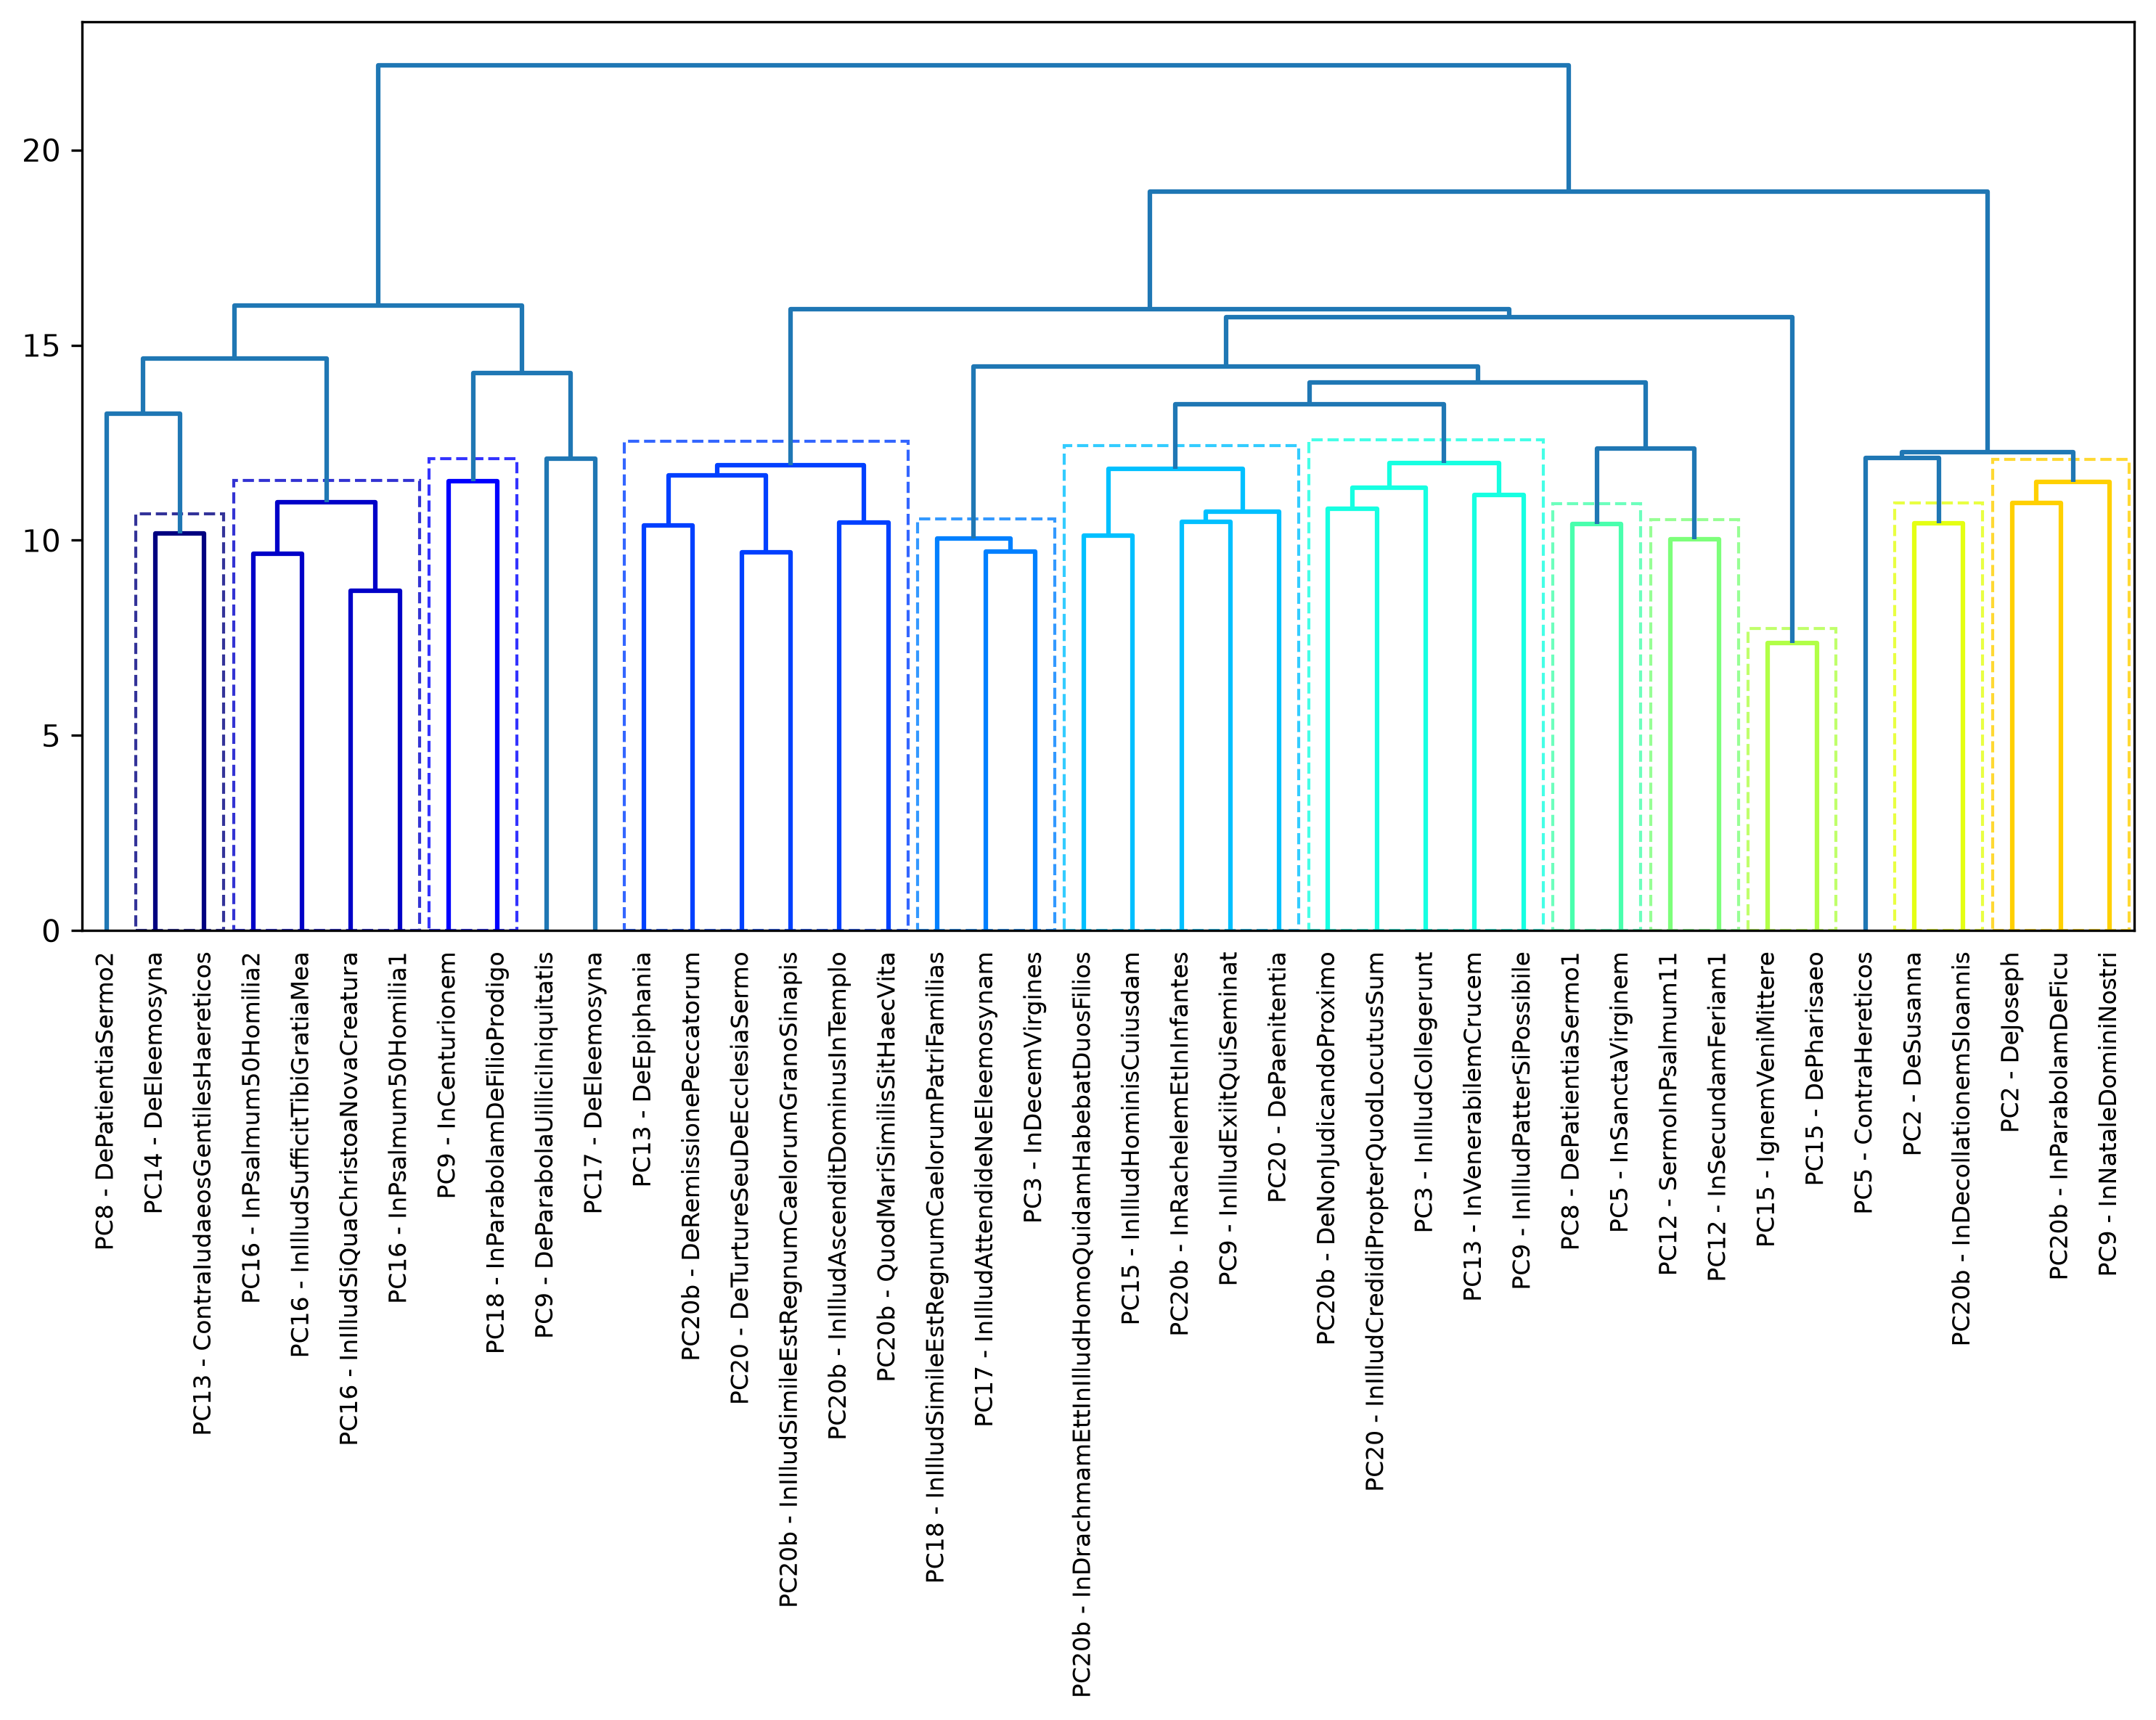

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=300)

fig.patch.set_facecolor('white')
### CAH has been moved out of dendo()
### TODO:
###   Probably separate dendo plotting and dendo acquisition ?
###   Figure out where does ETA2 and other goes
ax, dendogram_scipy_dict = classifier.plot_dendogram(ax=ax, k=K)
        
plt.xticks(rotation = 90)
plt.tight_layout()
plt.savefig("fwords-unsupervised.jpg")

## Analysis notes:

- PC16 is always grouped, despite having two homelias on the same subject (In Ps. 50, Hom.) 
- PC12 is indeed connected, but it could be due to its source (different OCR from the rest)
- PC15 has two texts that hold up well: De Phariseo & Ignem Veni Mittere.
- **Not true: bad reading** PC2 holds well (2/2) but joins a PC20b text (In Decollationem S. Ioannis)
- There is a 20(1)/20b(4) cluster (Quod Mari Similis; In Illud Ascendit; In Illus Similes Est Regnum; De Turture (20); De remissione) that is connected to a 13 text (De Epiphania)

Other classes do not hold up

## Feature / Class relationship: ETA2

In [10]:
eta2 = classifier.get_features_eta2(top=FEATURES)
eta2

,Eta 2,p-value
Class,,
ἣ,0.969714,6.951463e-16
ἔξωθεν,0.931491,2.217234e-11
οὐχὶ,0.838920,7.978748e-07
ἦν,0.795985,1.263159e-05
ἔχῃ,0.788328,1.926712e-05
πάντα,0.770278,4.874153e-05
τὰς,0.741657,1.798489e-04
οὐ,0.734487,2.426361e-04
τί,0.734127,2.462460e-04


In [11]:
# Align the most important features with our classes and documents
class_aligned_eta2, eta2_top_features = classifier.eta2_to_classes(eta2)
class_aligned_eta2

,ἣ,ἔξωθεν,οὐχὶ,ἦν,ἔχῃ,πάντα,τὰς,οὐ,τί,ἄλλοι,...,οὗ,ταῖς,πᾶσα,οὐδὲν,αὐτὰς,αὐτῇ,εἰμὶ,ἀλλὰ,πρὸ,Class
0,-0.021094,0.075158,-0.030188,0.030501,-0.022096,-0.025199,-0.098117,-0.094038,-0.059521,-0.027500,...,0.196058,0.071320,-0.039797,0.038445,0.108535,-0.055530,-0.035508,-0.073124,0.051071,7
1,-0.015348,-0.019754,-0.021965,0.007366,-0.016077,-0.033898,-0.013234,0.036531,0.035502,-0.020009,...,0.000021,-0.007916,-0.028957,-0.038427,0.040605,-0.001182,-0.025836,-0.015098,0.008650,10
2,-0.028130,0.045411,-0.040258,0.221497,-0.029467,-0.019032,-0.028357,-0.036115,-0.068839,-0.036672,...,-0.001855,0.354036,-0.053072,0.075174,-0.038132,0.135556,0.016166,-0.081307,-0.067785,16
3,-0.028202,0.042319,-0.040361,0.063489,-0.029542,0.148419,-0.034015,0.123990,-0.040631,-0.036766,...,-0.067611,-0.019606,0.036081,-0.070610,-0.038230,-0.074242,0.319627,0.199877,0.010346,4
4,-0.019302,0.026330,-0.027624,-0.057111,-0.020219,-0.046137,-0.013019,-0.118015,-0.030915,-0.025164,...,0.159325,-0.015811,-0.036417,-0.048327,-0.026165,0.036803,0.126809,-0.108056,-0.046512,7
5,-0.017166,-0.022093,-0.024566,-0.000874,-0.017981,-0.016742,-0.077837,-0.009716,0.131548,-0.022379,...,-0.041153,-0.014443,-0.032386,-0.042978,-0.023269,-0.045189,-0.028896,0.053754,-0.041364,10
6,0.301340,-0.023599,-0.026241,-0.072248,-0.019207,-0.070260,-0.027884,-0.046525,-0.038379,0.041928,...,0.054810,-0.059177,-0.034594,-0.009362,-0.024856,0.056954,-0.030866,0.006546,-0.003376,12
7,-0.014898,-0.019174,-0.021321,-0.058700,-0.015606,-0.057085,0.007567,-0.040952,0.028980,-0.019422,...,-0.035715,-0.009794,0.067634,-0.037299,-0.020195,-0.039218,-0.025078,0.057602,-0.035899,9
8,-0.015951,-0.020530,-0.022828,-0.062851,-0.016709,0.030856,-0.072103,0.091242,-0.075426,-0.020795,...,0.029722,-0.051481,0.258086,0.261838,-0.021623,0.102819,-0.026851,0.000217,-0.038438,11
9,-0.018132,-0.023337,-0.025950,0.015967,-0.018994,-0.069479,-0.087019,0.025782,-0.085738,-0.023639,...,-0.043470,-0.022770,0.144586,-0.045398,-0.024579,-0.047733,-0.030523,0.002966,-0.043693,7


/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

...

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,
/Users/chartja/Github/Chryso-Voicu/freestyl/unsupervised/dendogram.py:184: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sb.violinplot(data=eta2, x="Class", y=feature, ax=ax,


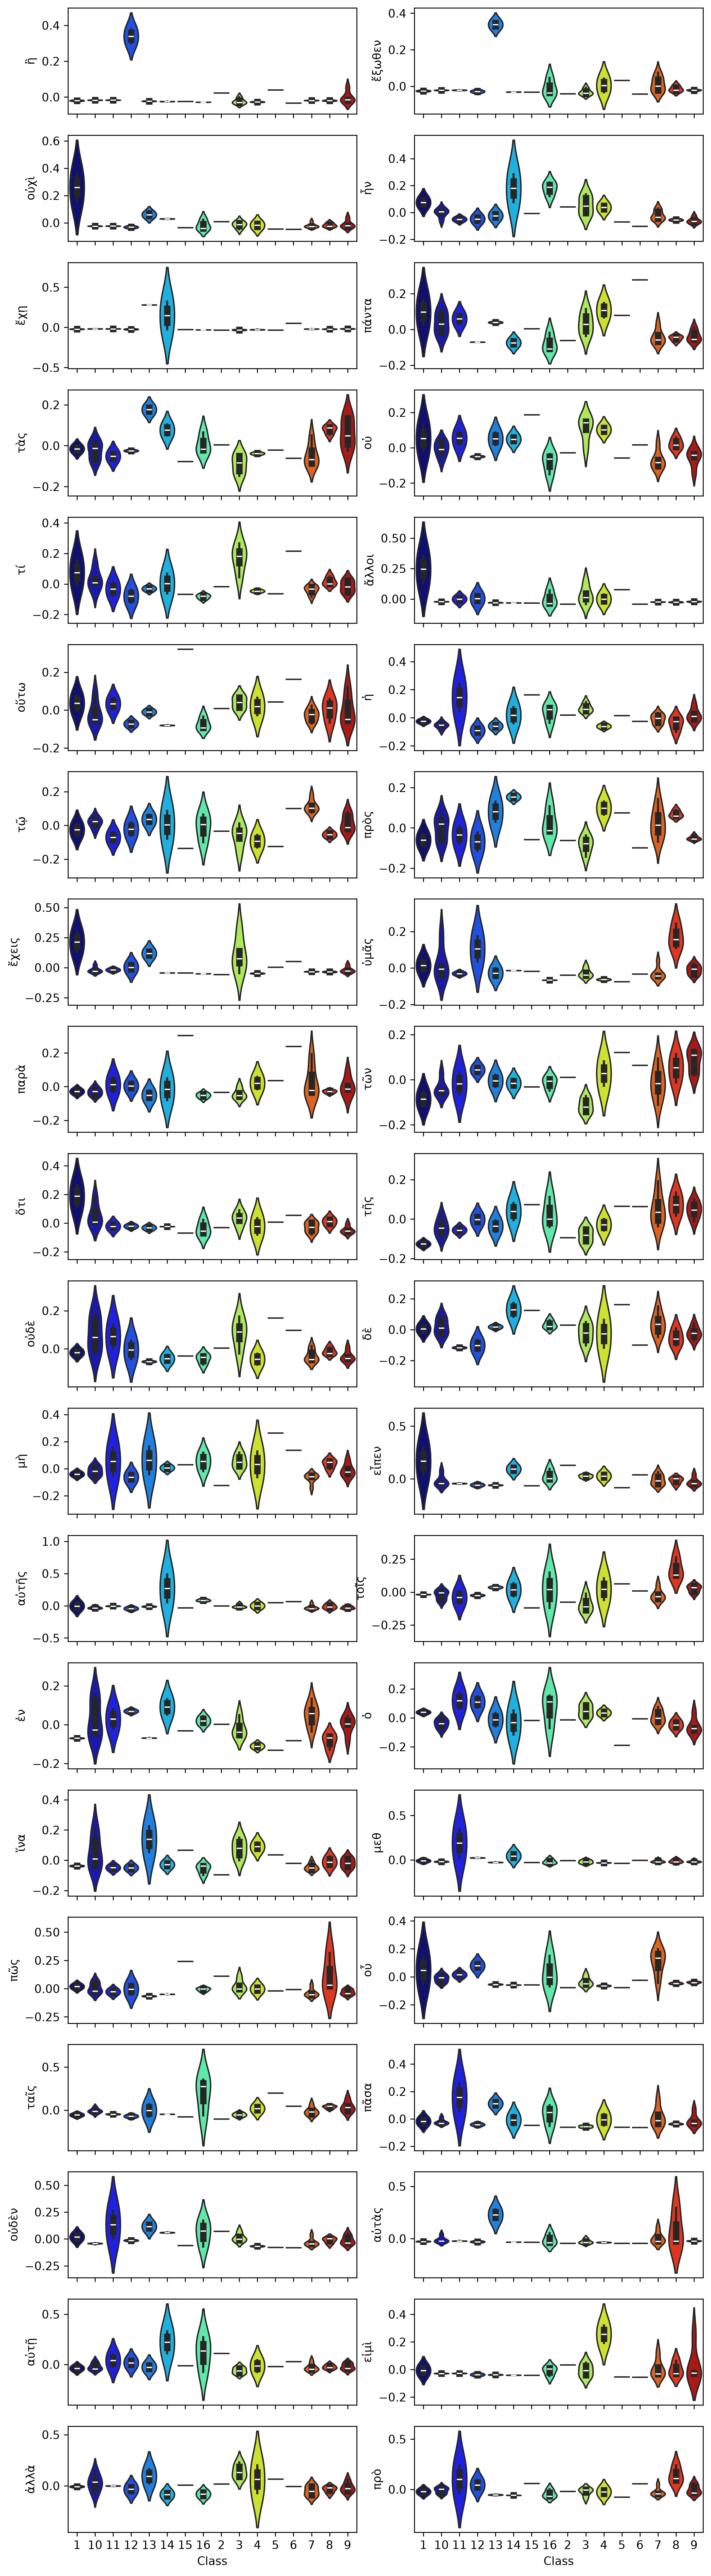

In [12]:
## Plot the distribution
fig, axes = classifier.plot_eta_2(class_aligned_eta2, eta2_top_features, fig_kwargs=dict(figsize=(10, 40), dpi=300))

plt.savefig("fwords-features.jpg")